## 1. Geração da base específica para o Prophet

Nesta etapa, a base geral tratada é carregada a partir do arquivo `trafego_tratado.csv` e adaptada ao formato exigido pelo Prophet.

Para evitar vazamento de informação, as variáveis `Sessões` e `Usuários ativos` não foram utilizadas como regressores, pois seus valores do próprio dia não seriam conhecidos em uma situação real de previsão.

## 2. Adequação ao formato do Prophet

O Prophet exige que a coluna de data seja chamada `ds` e que a variável a ser prevista seja chamada `y`. Por isso, a coluna `Data` foi renomeada para `ds` e a coluna `Visualizações` foi renomeada para `y`.

A base foi mantida em ordem cronológica e salva no arquivo `trafego_prophet_visualizacoes.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1. Geração da base específica para o Prophet
# ============================================================

df_tratado = pd.read_csv("../dados/trafego_tratado.csv")

df_tratado["Data"] = pd.to_datetime(df_tratado["Data"])
df_tratado = df_tratado.sort_values("Data").reset_index(drop=True)

# Base Prophet sem Sessões e Usuários ativos para evitar vazamento de informação
colunas_prophet = [
    "Data",
    "Visualizações",
    "fim_de_semana",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df = df_tratado[colunas_prophet].copy()

df = df.rename(columns={
    "Data": "ds",
    "Visualizações": "y"
})

df = df.sort_values("ds").reset_index(drop=True)

df.to_csv("../dados/trafego_prophet_visualizacoes.csv", index=False)

print("Arquivo salvo com sucesso: ../dados/trafego_prophet_visualizacoes.csv")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['ds'].min().date()} a {df['ds'].max().date()}")
print(df.head())
print(df.info())

Importing plotly failed. Interactive plots will not work.


Arquivo salvo com sucesso: ../dados/trafego_prophet_visualizacoes.csv
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
          ds      y  fim_de_semana  recesso_judiciario  feriado_nacional_fixo  \
0 2023-07-01   5566              1                   0                      0   
1 2023-07-02   5498              1                   0                      0   
2 2023-07-03  46786              0                   0                      0   
3 2023-07-04  44984              0                   0                      0   
4 2023-07-05  43559              0                   0                      0   

   carnaval  quarta_cinzas  sexta_paixao  corpus_christi  \
0         0              0             0               0   
1         0              0             0               0   
2         0              0             0               0   
3         0              0             0               0   
4         0              0             0               0   

   data_especifica_judic

19:51:14 - cmdstanpy - INFO - Chain [1] start processing
19:51:14 - cmdstanpy - INFO - Chain [1] done processing
19:51:14 - cmdstanpy - INFO - Chain [1] start processing


AVALIAÇÃO HOLDOUT - ÚLTIMOS 60 DIAS
RMSE: 6317.03
MAE : 5188.31
MAPE: 23.73%
R²  : 0.8505


19:51:14 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/8 [00:00<?, ?it/s]

19:51:14 - cmdstanpy - INFO - Chain [1] start processing
19:51:15 - cmdstanpy - INFO - Chain [1] done processing
19:51:15 - cmdstanpy - INFO - Chain [1] start processing
19:51:15 - cmdstanpy - INFO - Chain [1] done processing
19:51:15 - cmdstanpy - INFO - Chain [1] start processing
19:51:15 - cmdstanpy - INFO - Chain [1] done processing
19:51:15 - cmdstanpy - INFO - Chain [1] start processing
19:51:15 - cmdstanpy - INFO - Chain [1] done processing
19:51:16 - cmdstanpy - INFO - Chain [1] start processing
19:51:16 - cmdstanpy - INFO - Chain [1] done processing
19:51:16 - cmdstanpy - INFO - Chain [1] start processing
19:51:16 - cmdstanpy - INFO - Chain [1] done processing
19:51:16 - cmdstanpy - INFO - Chain [1] start processing
19:51:16 - cmdstanpy - INFO - Chain [1] done processing
19:51:16 - cmdstanpy - INFO - Chain [1] start processing
19:51:16 - cmdstanpy - INFO - Chain [1] done processing



VALIDAÇÃO CRUZADA TEMPORAL - RESULTADO AGREGADO
RMSE: 7571.09
MAE : 5583.74
MAPE: 70.45%
R²  : 0.8118

MÉTRICAS NATIVAS DO PROPHET (CV)
   horizon         rmse          mae      mape  coverage
0   6 days  5278.669551  4073.184621  0.452651  0.770833
1   7 days  6446.445641  4622.858698  0.511584  0.750000
2   8 days  7225.931762  4913.906684  0.746301  0.750000
3   9 days  7316.708734  4941.622873  0.875673  0.770833
4  10 days  7628.690935  5140.854252  0.821213  0.750000
5  11 days  8163.948473  5591.401855  0.865240  0.708333
6  12 days  7973.412627  5608.024962  1.032881  0.687500
7  13 days  7863.087955  5588.293021  1.048041  0.687500
8  14 days  7708.684890  5624.899017  0.909776  0.687500
9  15 days  8457.807274  6105.483668  1.024826  0.687500
10 16 days  8458.529800  6164.955520  1.179748  0.645833
11 17 days  7820.618181  5573.685798  1.024882  0.729167
12 18 days  8049.520964  5758.749078  1.021612  0.708333
13 19 days  7703.500236  5729.035470  1.121627  0.666667
14 20 da

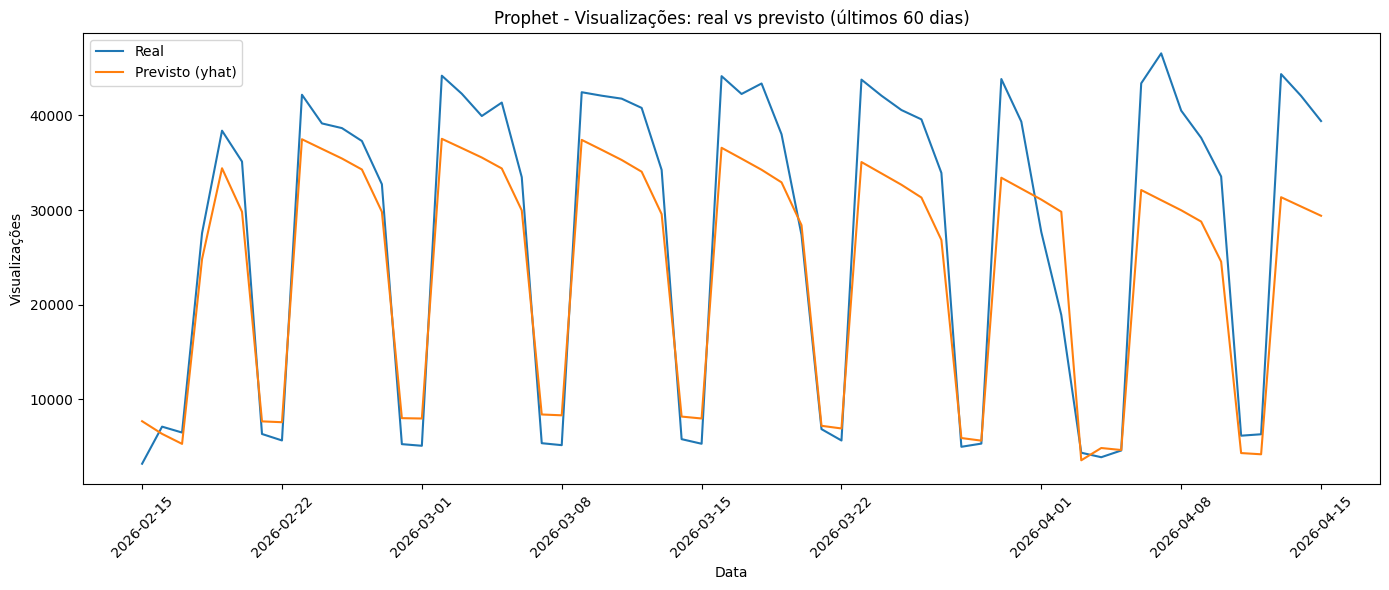

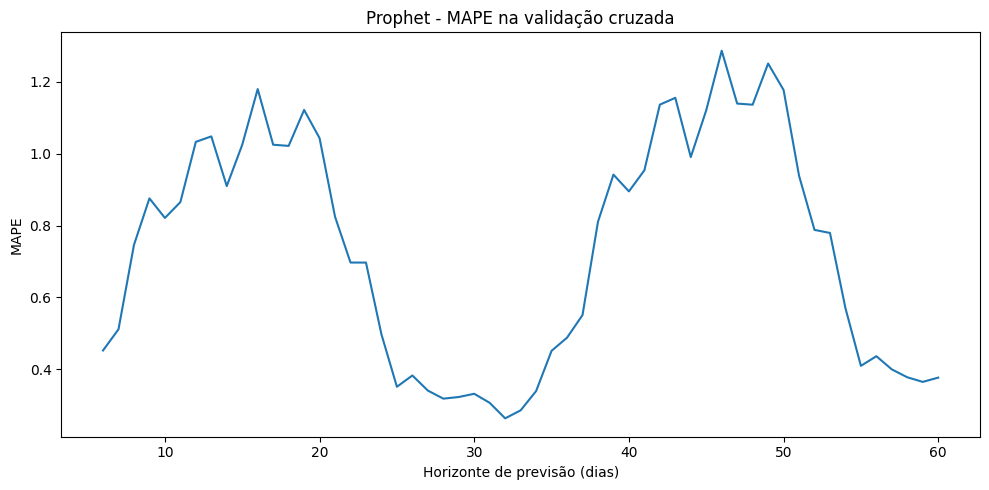

In [2]:
# ============================================================
# Configuração
# ============================================================
# Foram mantidas apenas variáveis de calendário conhecidas previamente,
# evitando o uso de informações do próprio dia previsto.

regressores = [
    "fim_de_semana",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

dias_teste = 60

# ============================================================
# 3. Funções auxiliares
# ============================================================
def calcular_mape(y_true, y_pred):
    """Retorna o MAPE em porcentagem."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Proteção contra divisão por zero
    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100


def criar_modelo_prophet():
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )

    for reg in regressores:
        modelo.add_regressor(reg)

    return modelo


# ============================================================
# 4. Separação treino / teste holdout
# ============================================================
colunas_modelo = ['ds', 'y'] + regressores

train = df.iloc[:-dias_teste][colunas_modelo].copy()
test = df.iloc[-dias_teste:][colunas_modelo].copy()

# ============================================================
# 5. Treinamento e previsão holdout
# ============================================================
modelo = criar_modelo_prophet()
modelo.fit(train)

forecast_test = modelo.predict(test[['ds'] + regressores])

y_real = test['y'].values
y_prev = forecast_test['yhat'].values

rmse_holdout = np.sqrt(mean_squared_error(y_real, y_prev))
mae_holdout = mean_absolute_error(y_real, y_prev)
mape_holdout = calcular_mape(y_real, y_prev)
r2_holdout = r2_score(y_real, y_prev)

print("=" * 60)
print("AVALIAÇÃO HOLDOUT - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"RMSE: {rmse_holdout:.2f}")
print(f"MAE : {mae_holdout:.2f}")
print(f"MAPE: {mape_holdout:.2f}%")
print(f"R²  : {r2_holdout:.4f}")

# ============================================================
# 6. Validação cruzada temporal do Prophet
# ============================================================
modelo_cv = criar_modelo_prophet()
modelo_cv.fit(df[colunas_modelo])

df_cv = cross_validation(
    modelo_cv,
    initial='730 days',
    period='30 days',
    horizon='60 days',
    parallel=None
)

# Métricas agregadas em todas as previsões fora da amostra da CV
rmse_cv = np.sqrt(mean_squared_error(df_cv['y'], df_cv['yhat']))
mae_cv = mean_absolute_error(df_cv['y'], df_cv['yhat'])
mape_cv = calcular_mape(df_cv['y'], df_cv['yhat'])
r2_cv = r2_score(df_cv['y'], df_cv['yhat'])

print("\n" + "=" * 60)
print("VALIDAÇÃO CRUZADA TEMPORAL - RESULTADO AGREGADO")
print("=" * 60)
print(f"RMSE: {rmse_cv:.2f}")
print(f"MAE : {mae_cv:.2f}")
print(f"MAPE: {mape_cv:.2f}%")
print(f"R²  : {r2_cv:.4f}")

# Métricas por horizonte usando a função nativa do Prophet
# rolling_window=0.1: curva suavizada por janela móvel
# rolling_window=1: tudo agregado em um ponto
# Aqui usamos 0.1 para gerar uma curva útil para gráfico.
df_metricas_cv = performance_metrics(df_cv, rolling_window=0.1)

print("\n" + "=" * 60)
print("MÉTRICAS NATIVAS DO PROPHET (CV)")
print("=" * 60)
print(df_metricas_cv[['horizon', 'rmse', 'mae', 'mape', 'coverage']])

# ============================================================
# 7. Gráficos
# ============================================================
# 7.1. Comparação real vs previsto no holdout
plt.figure(figsize=(14, 6))
plt.plot(test['ds'], y_real, label='Real')
plt.plot(test['ds'], y_prev, label='Previsto (yhat)')
plt.title('Prophet - Visualizações: real vs previsto (últimos 60 dias)')
plt.xlabel('Data')
plt.ylabel('Visualizações')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7.2. Curva de erro MAPE da validação cruzada
# Evita plot_cross_validation_metric(), que pode falhar em versões novas do pandas.
df_plot = df_metricas_cv.copy()
df_plot['horizon_dias'] = df_plot['horizon'].dt.days

plt.figure(figsize=(10, 5))
plt.plot(df_plot['horizon_dias'], df_plot['mape'])
plt.title('Prophet - MAPE na validação cruzada')
plt.xlabel('Horizonte de previsão (dias)')
plt.ylabel('MAPE')
plt.tight_layout()
plt.show()


## Salvamento de métricas do Prophet em CSV para comparação futura

In [3]:
metricas_prophet = pd.DataFrame({
    "modelo": ["Prophet Holdout", "Prophet CV"],
    "rmse": [rmse_holdout, rmse_cv],
    "mae": [mae_holdout, mae_cv],
    "mape": [mape_holdout, mape_cv],
    "r2": [r2_holdout, r2_cv]
})

metricas_prophet.to_csv("../dados/metricas_prophet.csv", index=False)

print("Métricas salvas em: ../dados/metricas_prophet.csv")
metricas_prophet

Métricas salvas em: ../dados/metricas_prophet.csv


,modelo,rmse,mae,mape,r2
0,Prophet Holdout,6317.028730,5188.312829,23.731997,0.850469
1,Prophet CV,7571.087028,5583.736351,70.451357,0.811763
